#  The data set called : bank_marketing_dataset

## 1. First of all , i need to diplay the dataset that i want to do changes on it : 

In [3]:
import numpy as  np
import pandas as pd

# display the data set to do changes on it :
df=pd.read_csv('C:\\Users\\husse\\Desktop\\Machine Learning\\DataSets\\bank_marketing_dataset.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79.0,1,-1.0,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220.0,1,339.0,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185.0,1,330.0,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199.0,4,-1.0,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226.0,1,-1.0,0,unknown,no


## 2. we need to transform the data from strings to numbers (In the state of two values only),Using LabelEncoder :

In [5]:
from sklearn.preprocessing import LabelEncoder

# apply the LabelEncoder preprocessing on the <housing> column:
L1=LabelEncoder();
L1.fit(df[['housing']])
df['Housing']=L1.transform(df[['housing']])

# apply the LabelEncoder preprocessing on the <loan> column:
L2=LabelEncoder();
L2.fit(df[['loan']])
df['Loan']=L2.transform(df[['loan']])

# apply the LabelEncoder preprocessing on the <y> column:
L3=LabelEncoder();
L3.fit(df[['y']])
df['Y']=L3.transform(df[['y']])

# apply the LabelEncoder preprocessing on the <default> column:
L4=LabelEncoder();
L4.fit(df[['default']])
df['Default']=L4.transform(df[['default']])

#droping the columns that we did a <label encoding> on it :
df=df.drop('housing',axis = 1)
df=df.drop('loan',axis = 1)
df=df.drop('y',axis = 1)
df=df.drop('default',axis = 1)


df.head()

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\husse\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\husse\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\husse\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

,age,job,marital,education,balance,contact,day,month,duration,campaign,pdays,previous,poutcome,Housing,Loan,Y,Default
0,30,unemployed,married,primary,1787,cellular,19,oct,79.0,1,-1.0,0,unknown,0,0,0,0
1,33,services,married,secondary,4789,cellular,11,may,220.0,1,339.0,4,failure,1,1,0,0
2,35,management,single,tertiary,1350,cellular,16,apr,185.0,1,330.0,1,failure,1,0,0,0
3,30,management,married,tertiary,1476,unknown,3,jun,199.0,4,-1.0,0,unknown,1,1,0,0
4,59,blue-collar,married,secondary,0,unknown,5,may,226.0,1,-1.0,0,unknown,1,0,0,0


## 3. For the columns that has more than two values in it , we need to apply a OneHotEncoding on it , to transform the data from string to numbers: there is a method (get_dummies) ,It creates new columns for each category in the specified column(s) and assigns a binary value (0 or 1) to indicate the presence of each category:

In [7]:
df = pd.get_dummies(df , columns = ['job'] , dtype = int)
df = pd.get_dummies(df , columns = ['marital'] , dtype = int)
df = pd.get_dummies(df , columns = ['education'] , dtype = int)
df = pd.get_dummies(df , columns = ['contact'] , dtype = int)
df = pd.get_dummies(df , columns = ['poutcome'] , dtype = int)
df = pd.get_dummies(df , columns = ['month'] , dtype = int)

df.head()

,age,balance,day,duration,campaign,pdays,previous,Housing,Loan,Y,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,30,1787,19,79.0,1,-1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,33,4789,11,220.0,1,339.0,4,1,1,0,...,0,0,0,0,0,0,1,0,0,0
2,35,1350,16,185.0,1,330.0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,30,1476,3,199.0,4,-1.0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
4,59,0,5,226.0,1,-1.0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [8]:
# so far , we have done preprocessing on the data set by using <label_encoding> and <one_hot_encoding> ,
# and transformed all the data into numbers.

## 4. Managing the (NULL) values :

In [10]:
# the last thing to do os to see if there is a null values so we make the model fill it with data from it's experience
# using <SimpleImputer> :
df.isnull().sum()

age                    0
balance                0
day                    0
duration               0
campaign               0
pdays                  0
previous               0
Housing                0
Loan                   0
Y                      0
Default                0
job_admin.             0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_divorced       0
marital_married        0
marital_single         0
education_primary      0
education_secondary    0
education_tertiary     0
education_unknown      0
contact_cellular       0
contact_telephone      0
contact_unknown        0
poutcome_failure       0
poutcome_other         0
poutcome_success       0
poutcome_unknown       0
month_apr              0
month_aug              0
month_dec              0


In [11]:
# that showes us that there is no <null> values in the data set ...
# but if there is any null values , that is the solution :
#      1. importing the library :
#         from sklearn.impute import SimpleImputer
#      2. creating an instence from it :
#         s = SimpleImuter(missing_values = nan , strategy = "the wanted strategy like <mean , max , min , .....>")
#         this code takes the missing_value = nan by defult ... so we dont need to use it in the code .
#         s = SimpleImputer(strategy = "mean")

#         s.fit(df[['Car']]) ....... it does not change the values .. it just apply the strategy and store a new value in the memory .
#         df['Car'] = s.transform(df[['Car']])  ....... it takes the new value and put it the fields that have "NULL" in it .
#      3. then we recheck if all the null values been transformed using :
#         df.isnull().sum()

## 5. Start machine learning : 

In [13]:
y = df[['Y']]
X = df[['age', 'poutcome_success', 'day', 'campaign', 'Loan', 'previous',
       'duration', 'balance', 'pdays', 'Default', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'education_primary', 'education_secondary',
       'education_tertiary', 'education_unknown', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'poutcome_failure',
       'poutcome_other', 'Housing', 'poutcome_unknown', 'month_apr',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep']]

### 1- Spliting the data into (Train_Data) and (Test_Data) : 

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

### 2- Apply Logistic Regression on the data: 

In [17]:
from sklearn.linear_model import LogisticRegression 
clf = LogisticRegression(max_iter = 100000).fit(x_train,y_train)
print('accuracy score (training)', clf.score(x_train,y_train))
print('accuracy score (test)', clf.score(x_test,y_test))

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy score (training) 0.901825221238938
accuracy score (test) 0.9093922651933701


C:\Users\husse\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Applying changes on LogisticRegression() parameters:

###### 1.. C = 20 , penalty = 'l1' , solver = 'liblinear':

In [20]:
clf2 = LogisticRegression(max_iter = 1000000 , C=20,  penalty='l1' , solver='liblinear').fit(x_train,y_train)
clf2
print('accuracy score (training)', clf2.score(x_train,y_train))
print('accuracy score (test)', clf2.score(x_test,y_test))

accuracy score (training) 0.9032079646017699
accuracy score (test) 0.9093922651933701


C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


###### 2.. C = 50 , penalty = 'l1' , solver = 'liblinear':

In [22]:
clf2 = LogisticRegression(max_iter = 1000000 , C=50,  penalty='l1' , solver='liblinear').fit(x_train,y_train)
clf2
print('accuracy score (training)', clf2.score(x_train,y_train))
print('accuracy score (test)', clf2.score(x_test,y_test))

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy score (training) 0.9032079646017699
accuracy score (test) 0.9082872928176795


### 3- Apply SVM on the data: 

In [24]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8816371681415929
0.8972375690607735


##### Applying changes on SVC() parameters:

###### 1.. C = 1.5 :

In [27]:
model = SVC(C = 1.5)
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8819137168141593
0.8961325966850828


###### 2.. C = 20:

In [29]:
model = SVC(C = 20)
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

C:\Users\husse\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8832964601769911
0.8972375690607735


### 4- Apply Decision Tree on the data: 

In [31]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

1.0
0.8696132596685083


##### Applying changes on DecisionTreeClassifier() parameters:

###### 1.. ccp_alpha = 2 :

In [34]:
model = DecisionTreeClassifier(ccp_alpha = 2)
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

0.8816371681415929
0.8972375690607735


###### 2.. ccp_alpha = 3 :

In [36]:
model = DecisionTreeClassifier(ccp_alpha = 3)
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

0.8816371681415929
0.8972375690607735


###### 3.. min_samples_split = 100 , max_features = 20 :

In [38]:
model = DecisionTreeClassifier(min_samples_split=100 ,max_features=20 )
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

0.9117809734513275
0.901657458563536


###### 4.. min_samples_split = 200 , max_features = 30 :

In [40]:
model = DecisionTreeClassifier(min_samples_split=200 ,max_features=30 )
model.fit(x_train , y_train)
print(model.score(x_train ,y_train))
print(model.score(x_test ,y_test))

0.9070796460176991
0.901657458563536


[Text(0.8431372549019608, 0.9736842105263158, 'x[6] <= 645.5\ngini = 0.209\nsamples = 3616\nvalue = [3188, 428]'),
 Text(0.7647058823529411, 0.9210526315789473, 'x[1] <= 0.5\ngini = 0.153\nsamples = 3332\nvalue = [3053, 279]'),
 Text(0.7254901960784313, 0.868421052631579, 'x[46] <= 0.5\ngini = 0.126\nsamples = 3243\nvalue = [3023, 220]'),
 Text(0.6862745098039216, 0.8157894736842105, 'x[0] <= 60.5\ngini = 0.116\nsamples = 3190\nvalue = [2992, 198]'),
 Text(0.6470588235294118, 0.7631578947368421, 'x[6] <= 349.5\ngini = 0.107\nsamples = 3116\nvalue = [2940, 176]'),
 Text(0.5098039215686274, 0.7105263157894737, 'x[6] <= 222.5\ngini = 0.064\nsamples = 2632\nvalue = [2545, 87]'),
 Text(0.43137254901960786, 0.6578947368421053, 'x[43] <= 0.5\ngini = 0.035\nsamples = 2032\nvalue = [1996, 36]'),
 Text(0.39215686274509803, 0.6052631578947368, 'x[18] <= 0.5\ngini = 0.032\nsamples = 2015\nvalue = [1982, 33]'),
 Text(0.35294117647058826, 0.5526315789473685, 'x[36] <= 0.5\ngini = 0.029\nsamples = 19

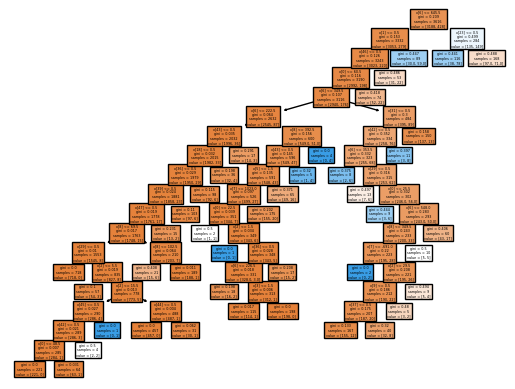

In [41]:
from sklearn.tree import plot_tree
plot_tree(model , filled = True)

## 6. Evaluation step :

In [64]:
from sklearn.metrics import confusion_matrix
y_predict = model.predict(x_test)
confusion = confusion_matrix(y_test , y_predict)
print('Support vector machine classifier (linear kernel , C = 1)\n' , confusion)

Support vector machine classifier (linear kernel , C = 1)
 [[778  34]
 [ 55  38]]


In [67]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
print('ACC is {}'.format(accuracy_score(y_test , y_predict)))
print('Precision is {:.2f}'.format(precision_score(y_test , y_predict)))
print('recall is {:.2f}'.format(recall_score(y_test , y_predict)))
print('f1 is {:.2f}'.format(f1_score(y_test , y_predict)))


ACC is 0.901657458563536
Precision is 0.53
recall is 0.41
f1 is 0.46


In [75]:
# to print the classification report : 
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predict))


              precision    recall  f1-score   support

           0       0.93      0.96      0.95       812
           1       0.53      0.41      0.46        93

    accuracy                           0.90       905
   macro avg       0.73      0.68      0.70       905
weighted avg       0.89      0.90      0.90       905

